In [38]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# Define known data points
x = np.array([0, 1, 2, 3, 4, 5])
y = np.array([0, 1, 0, 1, 0, 1])
# Create a cubic spline interpolation of the data


cs = CubicSpline(x, y, bc_type='natural')# Generate new x values for a smooth plot
x_interp = np.linspace(0, 5, 100)
y_interp = cs(x_interp)

Polynomial Coefficients:  [-5.85559710e-16  7.40740741e-02 -5.55555556e-01  1.10052910e+00
  6.34920635e-02]
Polynomial Coefficients: [-5.85559710e-16  7.40740741e-02 -5.55555556e-01  1.10052910e+00
  6.34920635e-02]


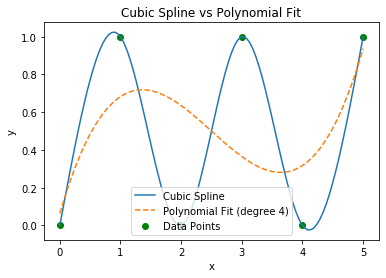

Mean Squared Error for polynomial: 0.16931216931216944
R-squared: 0.32275132275132223
Spline error: 0.0


In [39]:
degree = 4 # Degree of the polynomial
coefficients = np.polyfit(x, y, degree)
#Print the polynomial coefficients
print("Polynomial Coefficients: ", coefficients)
# Generate polynomial function based on the coefficients
polynomial = np.poly1d(coefficients)
# Generate predicted y-values based on the fitted polynomial
y_poly = polynomial(x_interp)

print("Polynomial Coefficients:", coefficients)
plt.scatter(x, y, color='green', label="Data Points")
plt.plot(x_interp, y_interp, label="Cubic Spline", linestyle='-')
plt.plot(x_interp, y_poly, label=f"Polynomial Fit (degree {degree})", linestyle='--')

plt.title("Cubic Spline vs Polynomial Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()


# Evaluate polynomial error
y_pred = polynomial(x)

mse = np.mean((y - y_pred)**2)
print("Mean Squared Error for polynomial:", mse)

ss_total = np.sum((y - np.mean(y))**2)
ss_res = np.sum((y - y_pred)**2)
r_squared = 1 - ss_res/ss_total
print("R-squared:", r_squared)

# Spline predictions at original points
y_spline_pred = cs(x)

# Spline error
mse_spline = np.mean((y - y_spline_pred)**2)
print("Spline error:", mse_spline)